# Analyse linguistique des 4 cas (P1 Finetuné vs KATE)

On analyse les **4 sous-ensembles** :
- **Les 2 se trompent** (00)
- **Les 2 ont raison** (11)
- **P1✓ KATE✗** (10) — complémentarité : finetuning seul correct
- **P1✗ KATE✓** (01) — complémentarité : few-shot seul correct

**Features calculées** :
1. **Chevauchement lexical** : % de mots en commun (prémisse ↔ hypothèse) — piège classique NLI (fort overlap → prédire Entailment à tort).
2. **Densité numérique** : chiffres, %, unités (mg, ans, etc.) — les essais cliniques ont beaucoup de seuils ; le few-shot peut être moins bon sur le raisonnement numérique.
3. **Négations** : "non", "aucun", "sans", "ne pas" — contradiction par négation simple vs antonymie complexe.
4. **Autres** : longueur (prémisse/hypothèse), type Single vs Comparison, vocabulaire "primary/secondary trial".

Objectif : voir si on peut **distinguer** ces 4 cas et en tirer des **conclusions** (où chaque approche est forte ou faible).

## 1. Configuration et chargement des données

In [76]:
from pathlib import Path
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

NLI4CT_ROOT = Path(".").resolve()
if not (NLI4CT_ROOT / "results").exists():
    NLI4CT_ROOT = NLI4CT_ROOT / "NLI4CT"
RESULTS_DIR_P1 = NLI4CT_ROOT / "results" / "Prompt 1"
RESULTS_DIR_KATE = NLI4CT_ROOT / "results" / "Fewshot_Kate"
FIGURES_DIR = NLI4CT_ROOT / "results" / "compare_figures_ft_vs_kate"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
GOLD_TEST_JSON = NLI4CT_ROOT / "Gold_test.json"
GOLD_JSONL_P1 = RESULTS_DIR_P1 / "Gold_test_formatted_old_prompt.jsonl" if (RESULTS_DIR_P1 / "Gold_test_formatted_old_prompt.jsonl").exists() else RESULTS_DIR_P1 / "Gold_test_formatted.jsonl"
CSV_FT_1 = next(RESULTS_DIR_P1.glob("pred_ft_*.csv"), None)
CSV_KATE = next(RESULTS_DIR_KATE.glob("pred_fewshot_KATE*.csv"), None)
assert CSV_FT_1 and CSV_KATE, "CSV P1 ou KATE manquant."

In [77]:
def extract_premise_hypothesis(text):
    if "HYPOTHESIS:" not in text:
        return text[:800] if len(text) > 800 else text, text[:500] if len(text) > 500 else text
    before, after = text.split("HYPOTHESIS:", 1)
    premise = before.replace("PREMISE:", "").strip()
    for sep in (".\n\nAnswer", "?\n\nAnswer", "? Answer", "\n\nAnswer"):
        if sep in after: after = after.split(sep)[0]
    return premise, after.strip()

df_ft_1 = pd.read_csv(CSV_FT_1)
df_kate = pd.read_csv(CSV_KATE)
for df in (df_ft_1, df_kate):
    if df['is_correct'].dtype == object:
        df['is_correct'] = df['is_correct'].apply(lambda x: str(x).strip().lower() == 'true')

meta_list = []
with open(GOLD_JSONL_P1, 'r', encoding='utf-8') as f:
    for idx, line in enumerate(f):
        if not line.strip(): continue
        obj = json.loads(line)
        msgs = obj.get("messages", [])
        if len(msgs) < 2: continue
        user_content = ""
        for m in msgs:
            if m.get("role") == "user": user_content = m.get("content", "")
        prem, stmt = extract_premise_hypothesis(user_content)
        meta_list.append({'index': idx, 'premise': prem, 'hypothesis': stmt})
df_meta = pd.DataFrame(meta_list)

common_idx = list(set(df_ft_1['index']) & set(df_kate['index']))
ok_p1 = df_ft_1.set_index('index').loc[common_idx, 'is_correct'].reindex(common_idx).fillna(False).values
ok_kate = df_kate.set_index('index').loc[common_idx, 'is_correct'].reindex(common_idx).fillna(False).values
acc = pd.DataFrame({'index': common_idx, 'P1_ft': ok_p1, 'KATE': ok_kate})
acc['pattern'] = acc['P1_ft'].astype(int).astype(str) + acc['KATE'].astype(int).astype(str)

df_base = df_meta[df_meta['index'].isin(common_idx)].copy()
df_base = df_base.merge(acc[['index','pattern']], on='index', how='inner')
if GOLD_TEST_JSON.exists():
    with open(GOLD_TEST_JSON, 'r', encoding='utf-8') as f: gold = json.load(f)
    keys = list(gold.keys())
    type_sec = pd.DataFrame([{'index': i, 'type': gold[keys[i]].get('Type','N/A'), 'section_id': gold[keys[i]].get('Section_id','N/A')} for i in range(len(keys))])
    df_base = df_base.merge(type_sec, on='index', how='left')

pattern_labels = {'11': 'Les 2 corrects', '00': 'Les 2 en erreur', '10': 'P1✓ KATE✗', '01': 'P1✗ KATE✓'}
df_base['pattern_label'] = df_base['pattern'].map(pattern_labels)
print('Effectifs par cas:')
print(df_base['pattern_label'].value_counts().sort_index())

Effectifs par cas:
pattern_label
Les 2 corrects     299
Les 2 en erreur     71
P1✓ KATE✗           72
P1✗ KATE✓           58
Name: count, dtype: int64


## 2. Fonctions d’analyse linguistique

In [78]:
def tokenize(text):
    """Mots en minuscules, alphanumeriques."""
    if pd.isna(text) or not isinstance(text, str): return set()
    return set(re.findall(r"[a-zA-Z0-9À-ÿ]+", text.lower()))

def lexical_overlap(premise, hypothesis):
    """Jaccard + % mots de l'hypothèse présents dans la prémisse (coverage)."""
    p, h = tokenize(premise), tokenize(hypothesis)
    if not p and not h: return 0.0, 0.0
    inter = len(p & h)
    union = len(p | h)
    jaccard = inter / union if union else 0.0
    coverage = inter / len(h) if h else 0.0  # % des mots de l'hypothèse dans la prémisse
    return jaccard, coverage

# Nombres en toutes lettres (anglais) pour numeric_density
NUMERIC_WORDS = frozenset({
    'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten',
    'eleven', 'twelve', 'thirteen', 'fourteen', 'fifteen', 'sixteen', 'seventeen', 'eighteen', 'nineteen',
    'twenty', 'thirty', 'forty', 'fifty', 'sixty', 'seventy', 'eighty', 'ninety',
    'hundred', 'thousand', 'million', 'billion',
    'first', 'second', 'third', 'fourth', 'fifth', 'sixth', 'seventh', 'eighth', 'ninth', 'tenth',
    'half', 'double', 'single', 'triple', 'zero',
})

def numeric_density(text):
    """Chiffres, pourcentages (\d+%), unités (mg, years, etc.), et nombres en toutes lettres."""
    if pd.isna(text) or not isinstance(text, str): return 0, 0, 0, 0
    digits = len(re.findall(r"\d", text))
    pct = len(re.findall(r"\d+%", text))
    units = len(re.findall(r"\d+\s*(?:mg|g|ml|mL|kg|years?|yrs?|months?|days?|weeks?|cycles?|doses?|mg/m²|m²)", text, re.I))
    t_lower = text.lower()
    words_num = sum(1 for w in re.findall(r"\b\w+\b", t_lower) if w in NUMERIC_WORDS)
    return digits, pct, units, words_num

# Détection des négations : NLTK (tokenize + liste de mots) si dispo, sinon regex
try:
    import nltk
    nltk.download('punkt', quiet=True)
    from nltk.tokenize import word_tokenize
    _NLTK_AVAILABLE = True
except Exception:
    _NLTK_AVAILABLE = False

# Mots de négation (anglais uniquement), utilisés avec ou sans NLTK. Les formes en n't sont comptées à part.
NEGATION_WORDS = frozenset({
    'not', 'no', 'none', 'never', 'nothing', 'nowhere', 'noone', 'nobody', 'neither', 'nor', 'cannot',
})

def negation_presence(text):
    """Compte d'occurrences de mots de négation (NEGATION_WORDS + tokens en n't)."""
    if pd.isna(text) or not isinstance(text, str): return 0
    t = text.strip().lower()
    if not t: return 0
    if _NLTK_AVAILABLE:
        try:
            tokens = word_tokenize(t)
        except Exception:
            tokens = re.findall(r"\b\w+\b", t)
    else:
        tokens = re.findall(r"\b\w+\b", t)
    return sum(1 for w in tokens if w in NEGATION_WORDS or (len(w) > 2 and w.endswith("n't")))

def trial_keywords(text):
    """Présence de mots clés 'primary' / 'secondary' (trial)."""
    if pd.isna(text) or not isinstance(text, str): return 0, 0
    t = text.lower()
    primary = len(re.findall(r"primary\s+(?:trial)?", t))
    secondary = len(re.findall(r"secondary\s+(?:trial)?", t))
    return primary, secondary

def word_count(text):
    if pd.isna(text) or not isinstance(text, str): return 0
    return len(re.findall(r"[a-zA-Z0-9À-ÿ]+", text))

In [79]:
# Appliquer les features à chaque ligne
def compute_features(row):
    prem, hyp = row['premise'], row['hypothesis']
    jaccard, coverage = lexical_overlap(prem, hyp)
    digits_p, pct_p, units_p, words_num_p = numeric_density(prem)
    digits_h, pct_h, units_h, words_num_h = numeric_density(hyp)
    neg_p = negation_presence(prem)
    neg_h = negation_presence(hyp)
    prim_p, sec_p = trial_keywords(prem)
    prim_h, sec_h = trial_keywords(hyp)
    return pd.Series({
        'lexical_jaccard': jaccard,
        'lexical_coverage': coverage,
        'digits_premise': digits_p,
        'digits_hypothesis': digits_h,
        'pct_premise': pct_p,
        'pct_hypothesis': pct_h,
        'units_premise': units_p,
        'units_hypothesis': units_h,
        'numeric_total': digits_p + digits_h + units_p + units_h + pct_p + pct_h + words_num_p + words_num_h,
        'neg_premise': neg_p,
        'neg_hypothesis': neg_h,
        'neg_total': neg_p + neg_h,
        'words_premise': word_count(prem),
        'words_hypothesis': word_count(hyp),
        'trial_primary': prim_p + prim_h,
        'trial_secondary': sec_p + sec_h,
    })

df_feat = df_base.join(df_base.apply(compute_features, axis=1))
df_feat.head(3)

,index,premise,hypothesis,pattern,type,section_id,pattern_label,lexical_jaccard,lexical_coverage,digits_premise,...,units_premise,units_hypothesis,numeric_total,neg_premise,neg_hypothesis,neg_total,words_premise,words_hypothesis,trial_primary,trial_secondary
0,0,Exclusion Criteria:\n History of bilateral ma...,Women suffering from both claustrophobia and I...,11,Comparison,Eligibility,Les 2 corrects,0.076923,0.125000,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,14.0,19.0,1.0,1.0
1,1,Inclusion Criteria:\n Women 18 years\n Histo...,There are no conditions on mental mental healt...,00,Single,Eligibility,Les 2 en erreur,0.066667,0.133333,3.0,...,1.0,0.0,4.0,0.0,1.0,1.0,41.0,33.0,1.0,0.0
2,2,Inclusion Criteria:\n Patients presenting for...,the secondary trial requires patients to be ov...,11,Comparison,Eligibility,Les 2 corrects,0.055556,0.200000,5.0,...,1.0,0.0,6.0,0.0,1.0,1.0,79.0,23.0,1.0,1.0


## 3. Statistiques descriptives par cas (4 groupes)

In [80]:
feat_cols = ['lexical_jaccard', 'lexical_coverage', 'numeric_total', 'neg_total', 'words_premise', 'words_hypothesis']
summary = df_feat.groupby('pattern_label')[feat_cols].agg(['mean', 'median', 'std', 'count']).round(4)
display(summary)
print('\n--- Moyennes par cas (pour comparaison rapide) ---')
means = df_feat.groupby('pattern_label')[feat_cols].mean().round(4)
display(means)

lexical_jaccard                       lexical_coverage  \
                           mean  median     std count             mean   
pattern_label                                                            
Les 2 corrects           0.1045  0.0882  0.0787   299           0.3354   
Les 2 en erreur          0.1050  0.0870  0.0767    71           0.3799   
P1✓ KATE✗                0.1073  0.0785  0.0784    72           0.3553   
P1✗ KATE✓                0.1004  0.0833  0.0670    58           0.3958   

                                      numeric_total         ... neg_total  \
                 median     std count          mean median  ...       std   
pattern_label                                               ...             
Les 2 corrects   0.3158  0.2127   299       41.7926   27.0  ...    1.2738   
Les 2 en erreur  0.3913  0.1883    71       40.6620   34.0  ...    3.9042   
P1✓ KATE✗        0.3333  0.2082    72       43.7222   26.5  ...    1.6525   
P1✗ KATE✓        0.3944  0.2153    58       62.7414   46.5  ...    3.3089   

                      words_premise                        words_hypothesis  \
                count          mean median       std count             mean   
pattern_label                                                                 
Les 2 corrects    299      113.4281   81.0  106.5442   299          21.4950   
Les 2 en erreur    71      169.0563   94.0  220.4111    71          21.5070   
P1✓ KATE✗          72      124.2639  112.0   92.7269    72          22.5417   
P1✗ KATE✓          58      220.8448  147.5  288.4716    58          24.4655   

                                      
                median     std count  
pattern_label                         
Les 2 corrects    21.0  7.2117   299  
Les 2 en erreur   21.0  7.4025    71  
P1✓ KATE✗         21.0  8.1239    72  
P1✗ KATE✓         24.0  7.8388    58  

[4 rows x 24 columns]


--- Moyennes par cas (pour comparaison rapide) ---


,lexical_jaccard,lexical_coverage,numeric_total,neg_total,words_premise,words_hypothesis
pattern_label,,,,,,
Les 2 corrects,0.1045,0.3354,41.7926,0.6756,113.4281,21.4950
Les 2 en erreur,0.1050,0.3799,40.6620,1.9859,169.0563,21.5070
P1✓ KATE✗,0.1073,0.3553,43.7222,0.8750,124.2639,22.5417
P1✗ KATE✓,0.1004,0.3958,62.7414,1.4138,220.8448,24.4655


## 4. Visualisations par feature (boxplots / barres)

/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_60776/298756287.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_60776/298756287.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_60776/298756287.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_60776/298756287.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e.

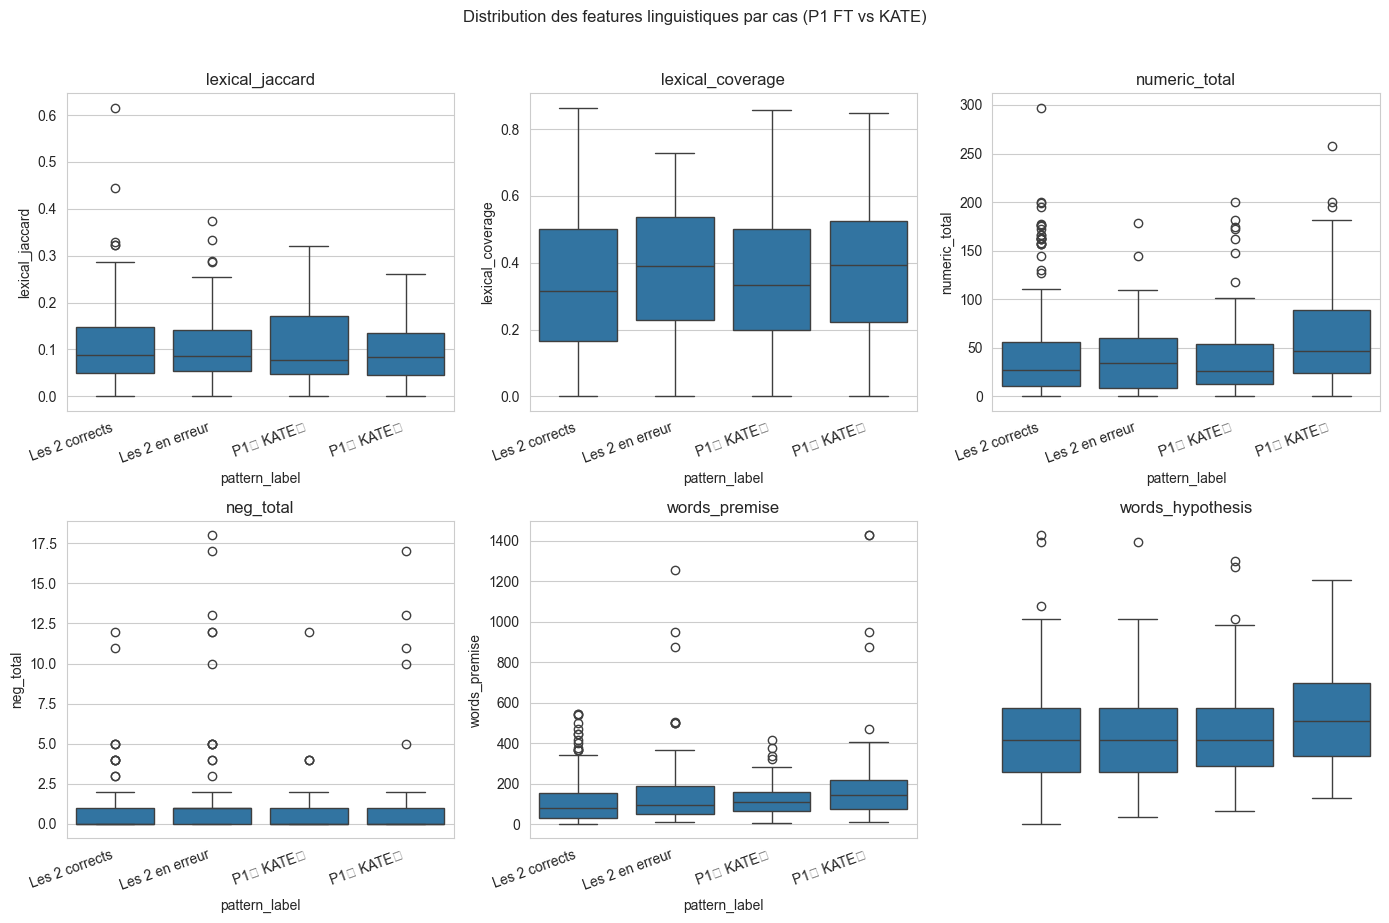

In [81]:
order = ['Les 2 corrects', 'Les 2 en erreur', 'P1✓ KATE✗', 'P1✗ KATE✓']
df_plot = df_feat[df_feat['pattern_label'].isin(order)].copy()
df_plot['pattern_label'] = pd.Categorical(df_plot['pattern_label'], categories=order, ordered=True)
df_plot = df_plot.sort_values('pattern_label')

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()
for i, col in enumerate(feat_cols):
    ax = axes[i]
    sns.boxplot(data=df_plot, x='pattern_label', y=col, ax=ax, order=order)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
    ax.set_title(col)
axes[-1].axis('off')
plt.suptitle('Distribution des features linguistiques par cas (P1 FT vs KATE)', y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'linguistic_boxplots_4_cas.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_60776/3059109442.py:13: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_60776/3059109442.py:13: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_60776/3059109442.py:14: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.savefig(FIGURES_DIR / 'linguistic_means_4_cas.png', dpi=150, bbox_inches='tight')
/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_60776/3059109442.py:14: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.savefig(FIGURES_DIR / 'linguistic_means_4_cas.png', dpi=150, bbox_inches='tight')
/Users/lubin/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.p

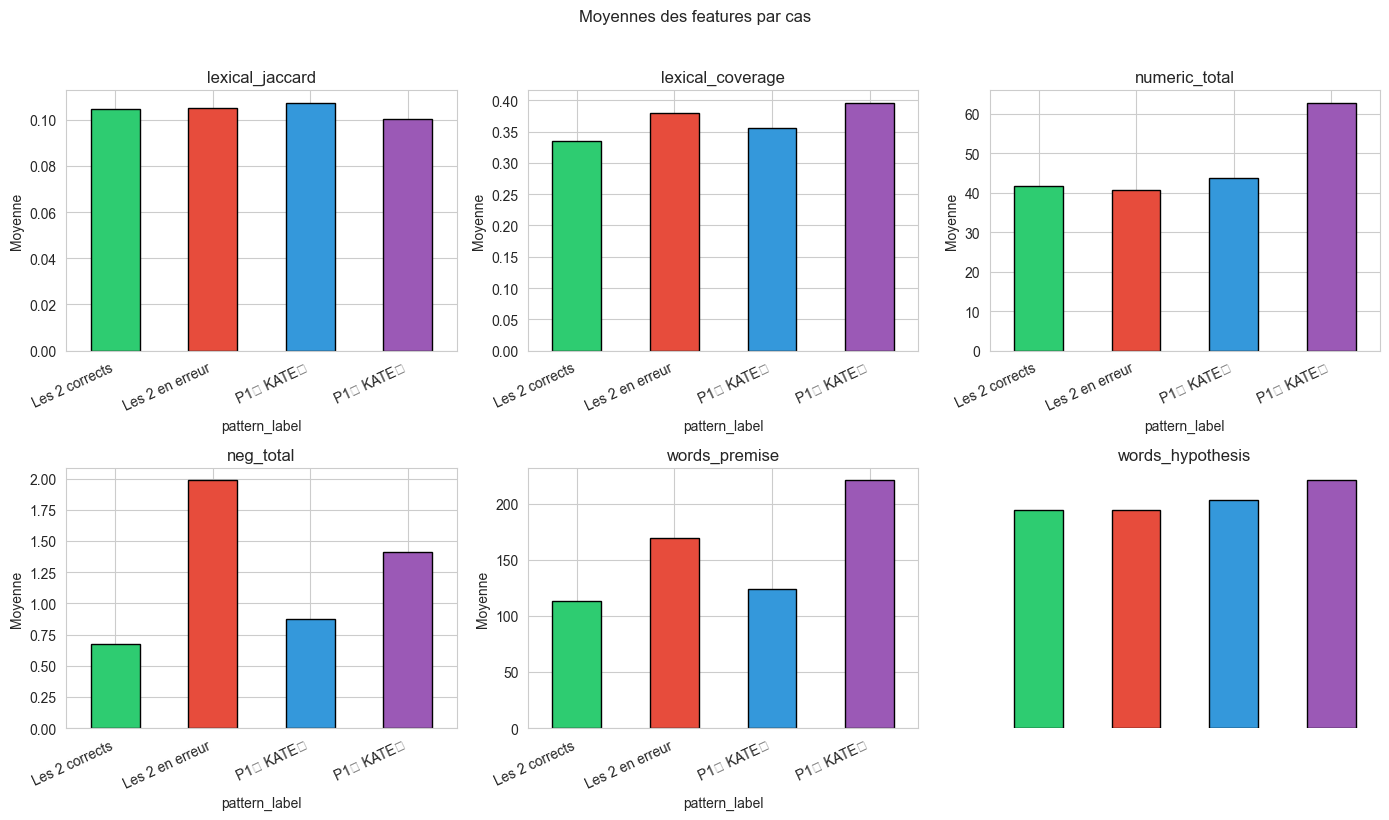

In [82]:
# Moyennes en barres pour lecture plus directe
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(feat_cols):
    ax = axes[i]
    m = df_feat.groupby('pattern_label')[col].mean().reindex(order).dropna()
    m.plot(kind='bar', ax=ax, color=['#2ecc71','#e74c3c','#3498db','#9b59b6'], edgecolor='black')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
    ax.set_title(col)
    ax.set_ylabel('Moyenne')
axes[-1].axis('off')
plt.suptitle('Moyennes des features par cas', y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'linguistic_means_4_cas.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Analyse ciblée : Chevauchement lexical

In [83]:
print('Hypothèse : fort chevauchement lexical → les modèles prédiraient Entailment à tort (contradiction subtile).')
print('On compare Jaccard et coverage entre "Les 2 en erreur" vs "Les 2 corrects".\n')
for label in ['Les 2 en erreur', 'Les 2 corrects']:
    sub = df_feat[df_feat['pattern_label'] == label]
    print(f"{label}: Jaccard moyen = {sub['lexical_jaccard'].mean():.3f}, coverage moyen = {sub['lexical_coverage'].mean():.3f} (n={len(sub)})")
print()
print('Comparaison P1✓ KATE✗ vs P1✗ KATE✓ (complémentarité) :')
for label in ['P1✓ KATE✗', 'P1✗ KATE✓']:
    sub = df_feat[df_feat['pattern_label'] == label]
    print(f"{label}: Jaccard = {sub['lexical_jaccard'].mean():.3f}, coverage = {sub['lexical_coverage'].mean():.3f}")

Hypothèse : fort chevauchement lexical → les modèles prédiraient Entailment à tort (contradiction subtile).
On compare Jaccard et coverage entre "Les 2 en erreur" vs "Les 2 corrects".

Les 2 en erreur: Jaccard moyen = 0.105, coverage moyen = 0.380 (n=71)
Les 2 corrects: Jaccard moyen = 0.104, coverage moyen = 0.335 (n=299)

Comparaison P1✓ KATE✗ vs P1✗ KATE✓ (complémentarité) :
P1✓ KATE✗: Jaccard = 0.107, coverage = 0.355
P1✗ KATE✓: Jaccard = 0.100, coverage = 0.396


## 6. Analyse ciblée : Densité numérique

In [84]:
print('Hypothèse : cas avec plus de chiffres/unités → KATE (few-shot) pourrait plus souvent se tromper (raisonnement numérique).')
print('On compare numeric_total (chiffres + % + unités) entre les 4 cas.\n')
for label in order:
    sub = df_feat[df_feat['pattern_label'] == label]
    print(f"{label}: numeric_total moyen = {sub['numeric_total'].mean():.1f}, units_premise = {sub['units_premise'].mean():.1f}, units_hypothesis = {sub['units_hypothesis'].mean():.1f}")
print()
print('Si P1✗ KATE✓ a une densité numérique plus élevée → KATE gère mieux le numérique dans ces exemples.')

Hypothèse : cas avec plus de chiffres/unités → KATE (few-shot) pourrait plus souvent se tromper (raisonnement numérique).
On compare numeric_total (chiffres + % + unités) entre les 4 cas.

Les 2 corrects: numeric_total moyen = 41.8, units_premise = 3.2, units_hypothesis = 0.2
Les 2 en erreur: numeric_total moyen = 40.7, units_premise = 4.1, units_hypothesis = 0.2
P1✓ KATE✗: numeric_total moyen = 43.7, units_premise = 2.8, units_hypothesis = 0.2
P1✗ KATE✓: numeric_total moyen = 62.7, units_premise = 4.3, units_hypothesis = 0.1

Si P1✗ KATE✓ a une densité numérique plus élevée → KATE gère mieux le numérique dans ces exemples.


## 7. Analyse ciblée : Négations

In [85]:
print('Hypothèse : plus de négations → contradiction par négation explicite vs antonymie/complexe.')
print('Comparaison neg_total (prémisse + hypothèse) entre les 4 cas.\n')
for label in order:
    sub = df_feat[df_feat['pattern_label'] == label]
    print(f"{label}: neg_total moyen = {sub['neg_total'].mean():.2f}, neg_hypothesis = {sub['neg_hypothesis'].mean():.2f}")
print()
print('Vérification par type (Single vs Comparison) :')
if 'type' in df_feat.columns:
    display(df_feat.groupby(['pattern_label','type']).size().unstack(fill_value=0))

Hypothèse : plus de négations → contradiction par négation explicite vs antonymie/complexe.
Comparaison neg_total (prémisse + hypothèse) entre les 4 cas.

Les 2 corrects: neg_total moyen = 0.68, neg_hypothesis = 0.23
Les 2 en erreur: neg_total moyen = 1.99, neg_hypothesis = 0.32
P1✓ KATE✗: neg_total moyen = 0.88, neg_hypothesis = 0.29
P1✗ KATE✓: neg_total moyen = 1.41, neg_hypothesis = 0.24

Vérification par type (Single vs Comparison) :


type,Comparison,Single
pattern_label,,
Les 2 corrects,156,143
Les 2 en erreur,39,32
P1✓ KATE✗,39,33
P1✗ KATE✓,37,21


## 9. Synthèse et conclusions

In [86]:
conclusions = []
for label in order:
    sub = df_feat[df_feat['pattern_label'] == label]
    conclusions.append({
        'Cas': label,
        'n': len(sub),
        'Jaccard_moy': sub['lexical_jaccard'].mean(),
        'numeric_moy': sub['numeric_total'].mean(),
        'neg_moy': sub['neg_total'].mean(),
        'words_prem_moy': sub['words_premise'].mean(),
    })
df_concl = pd.DataFrame(conclusions)
display(df_concl.round(4))

print('\n--- Interprétation possible ---')
print('• Les 2 en erreur : si Jaccard élevé → piège lexical (overlap). Si numeric élevé → difficulté numérique partagée.')
print('• Les 2 corrects : baseline "facile" ; à comparer aux autres pour voir quelles features distinguent le facile du difficile.')
print('• P1✓ KATE✗ : cas où le finetuning réussit et KATE échoue ; si numeric élevé → finetuning plus robuste au numérique.')
print('• P1✗ KATE✓ : cas où KATE réussit et le finetuning échoue ; si neg ou lexical particulier → KATE meilleur sur ces profils.')

,Cas,n,Jaccard_moy,numeric_moy,neg_moy,words_prem_moy
0,Les 2 corrects,299,0.1045,41.7926,0.6756,113.4281
1,Les 2 en erreur,71,0.1050,40.6620,1.9859,169.0563
2,P1✓ KATE✗,72,0.1073,43.7222,0.8750,124.2639
3,P1✗ KATE✓,58,0.1004,62.7414,1.4138,220.8448



--- Interprétation possible ---
• Les 2 en erreur : si Jaccard élevé → piège lexical (overlap). Si numeric élevé → difficulté numérique partagée.
• Les 2 corrects : baseline "facile" ; à comparer aux autres pour voir quelles features distinguent le facile du difficile.
• P1✓ KATE✗ : cas où le finetuning réussit et KATE échoue ; si numeric élevé → finetuning plus robuste au numérique.
• P1✗ KATE✓ : cas où KATE réussit et le finetuning échoue ; si neg ou lexical particulier → KATE meilleur sur ces profils.


## 8b. Test de significativité (Kruskal-Wallis)

Vérifier si les distributions des features diffèrent significativement entre les 4 groupes.

In [87]:
from scipy import stats
groups = [df_feat.loc[df_feat['pattern_label']==l, col].values for l in order for col in feat_cols]
results = []
for col in feat_cols:
    g = [df_feat.loc[df_feat['pattern_label']==l, col].dropna().values for l in order]
    g = [x for x in g if len(x) > 0]
    if len(g) >= 2:
        h, p = stats.kruskal(*g)
        results.append({'feature': col, 'H': h, 'p_value': p})
df_kw = pd.DataFrame(results)
df_kw['significatif_5%'] = df_kw['p_value'] < 0.05
display(df_kw.round(4))
print('Si p_value < 0.05 : les 4 groupes diffèrent significativement sur cette feature.')

,feature,H,p_value,significatif_5%
0,lexical_jaccard,0.0808,0.9940,False
1,lexical_coverage,5.8735,0.1179,False
2,numeric_total,11.2908,0.0103,True
3,neg_total,5.4128,0.1439,False
4,words_premise,15.1051,0.0017,True
5,words_hypothesis,7.7835,0.0507,False


Si p_value < 0.05 : les 4 groupes diffèrent significativement sur cette feature.


## 10. Export du tableau enrichi

In [88]:
out_path = FIGURES_DIR / 'analyse_linguistique_4_cas.csv'
df_feat.to_csv(out_path, index=False)
print('Exporté:', out_path)

Exporté: /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/compare_figures_ft_vs_kate/analyse_linguistique_4_cas.csv


## 9. Focus linguistique sur la section *Eligibility*

On refait la même analyse que ci-dessus (4 cas : *Les 2 corrects*, *Les 2 en erreur*, *P1✓ KATE✗*, *P1✗ KATE✓*), mais en se restreignant aux exemples dont la section est **Eligibility**. Cela sert de transition vers l'analyse d'erreurs NLI4PR, centrée sur des tâches d'éligibilité.

**Analyse univariée par modèle** : deux tableaux supplémentaires comparent les métriques linguistiques selon que le **few-shot (KATE)** a raison ou se trompe, puis selon que le **finetuning (P1)** a raison ou se trompe, afin d’identifier les profils d’exemples associés aux succès/échecs de chaque approche.

In [89]:
# Sous-ensemble Eligibility
df_elig = df_feat[df_feat["section_id"] == "Eligibility"].copy()
print("Effectifs par cas (Eligibility seulement) :")
print(df_elig["pattern_label"].value_counts().sort_index())
print()

feat_cols = ["lexical_jaccard", "lexical_coverage", "numeric_total", "neg_total", "words_premise", "words_hypothesis"]

# Statistiques descriptives (même format que section 3)
summary_elig = df_elig.groupby("pattern_label")[feat_cols].agg(["mean", "median", "std", "count"]).round(4)
display(summary_elig)

print("\n--- Moyennes par cas (Eligibility, pour comparaison rapide) ---")
means_elig = df_elig.groupby("pattern_label")[feat_cols].mean().round(4)
display(means_elig)

# Kruskal-Wallis sur Eligibility
from scipy import stats
order = ["Les 2 corrects", "Les 2 en erreur", "P1✓ KATE✗", "P1✗ KATE✓"]
results_elig = []
for col in feat_cols:
    groups_elig = [df_elig.loc[df_elig["pattern_label"] == lab, col].dropna().values for lab in order]
    groups_elig = [g for g in groups_elig if len(g) > 0]
    if len(groups_elig) >= 2:
        h, p = stats.kruskal(*groups_elig)
        results_elig.append({"feature": col, "H": h, "p_value": p})
df_kw_elig = pd.DataFrame(results_elig)
df_kw_elig["significatif_5%"] = df_kw_elig["p_value"] < 0.05
print("\nKruskal-Wallis (Eligibility seulement) :")
display(df_kw_elig.round(4))

# Analyse univariée : Few-shot (KATE) — métriques quand KATE a raison vs quand KATE se trompe
df_elig["KATE_correct"] = df_elig["pattern"].str[1] == "1"
table_fewshot_elig = df_elig.groupby("KATE_correct")[feat_cols].agg(["mean", "median", "std", "count"]).round(4)
table_fewshot_elig.index = ["KATE se trompe (Eligibility)", "KATE a raison (Eligibility)"]
print("\n--- Analyse univariée Few-shot (KATE), section Eligibility ---")
display(table_fewshot_elig)

# Analyse univariée : Finetuning (P1) — métriques quand P1 a raison vs quand P1 se trompe
df_elig["P1_ft_correct"] = df_elig["pattern"].str[0] == "1"
table_finetuning_elig = df_elig.groupby("P1_ft_correct")[feat_cols].agg(["mean", "median", "std", "count"]).round(4)
table_finetuning_elig.index = ["P1 se trompe (Eligibility)", "P1 a raison (Eligibility)"]
print("\n--- Analyse univariée Finetuning (P1), section Eligibility ---")
display(table_finetuning_elig)

Effectifs par cas (Eligibility seulement) :
pattern_label
Les 2 corrects     70
Les 2 en erreur    26
P1✓ KATE✗          21
P1✗ KATE✓          15
Name: count, dtype: int64



lexical_jaccard                       lexical_coverage  \
                           mean  median     std count             mean   
pattern_label                                                            
Les 2 corrects           0.1221  0.1094  0.1003    70           0.3574   
Les 2 en erreur          0.1125  0.0863  0.0934    26           0.4575   
P1✓ KATE✗                0.0876  0.0643  0.0635    21           0.3385   
P1✗ KATE✓                0.0891  0.0803  0.0628    15           0.5265   

                                      numeric_total         ... neg_total  \
                 median     std count          mean median  ...       std   
pattern_label                                               ...             
Les 2 corrects   0.3515  0.2026    70       10.9857    6.0  ...    2.1126   
Les 2 en erreur  0.5100  0.1908    26       20.3462    9.0  ...    5.6411   
P1✓ KATE✗        0.3571  0.1650    21       14.5714   12.0  ...    2.6440   
P1✗ KATE✓        0.5263  0.2357    15       35.6000   26.0  ...    5.3408   

                      words_premise                        words_hypothesis  \
                count          mean median       std count             mean   
pattern_label                                                                 
Les 2 corrects     70       97.1857   62.0  118.6569    70          22.8286   
Les 2 en erreur    26      247.1154   99.0  322.4586    26          23.5769   
P1✓ KATE✗          21      131.7143  130.0  104.9915    21          24.2857   
P1✗ KATE✓          15      447.4667  284.0  488.1190    15          28.2667   

                                      
                median     std count  
pattern_label                         
Les 2 corrects    23.0  6.8567    70  
Les 2 en erreur   22.5  9.4453    26  
P1✓ KATE✗         24.0  8.2471    21  
P1✗ KATE✓         30.0  9.0275    15  

[4 rows x 24 columns]


--- Moyennes par cas (Eligibility, pour comparaison rapide) ---


,lexical_jaccard,lexical_coverage,numeric_total,neg_total,words_premise,words_hypothesis
pattern_label,,,,,,
Les 2 corrects,0.1221,0.3574,10.9857,1.1714,97.1857,22.8286
Les 2 en erreur,0.1125,0.4575,20.3462,4.3077,247.1154,23.5769
P1✓ KATE✗,0.0876,0.3385,14.5714,1.9048,131.7143,24.2857
P1✗ KATE✓,0.0891,0.5265,35.6000,4.6667,447.4667,28.2667



Kruskal-Wallis (Eligibility seulement) :


,feature,H,p_value,significatif_5%
0,lexical_jaccard,3.1153,0.3742,False
1,lexical_coverage,12.3491,0.0063,True
2,numeric_total,11.4216,0.0097,True
3,neg_total,18.3443,0.0004,True
4,words_premise,16.0017,0.0011,True
5,words_hypothesis,5.9383,0.1146,False



--- Analyse univariée Few-shot (KATE), section Eligibility ---


lexical_jaccard                        \
                                        mean  median     std count   
KATE se trompe (Eligibility)          0.1014  0.0714  0.0815    47   
KATE a raison (Eligibility)           0.1163  0.1034  0.0953    85   

                             lexical_coverage                        \
                                         mean  median     std count   
KATE se trompe (Eligibility)           0.4044  0.4074  0.1876    47   
KATE a raison (Eligibility)            0.3872  0.4074  0.2172    85   

                             numeric_total         ... neg_total        \
                                      mean median  ...       std count   
KATE se trompe (Eligibility)       17.7660   11.0  ...    4.6682    47   
KATE a raison (Eligibility)        15.3294    6.0  ...    3.1963    85   

                             words_premise                         \
                                      mean median       std count   
KATE se trompe (Eligibility)      195.5532  125.0  254.2962    47   
KATE a raison (Eligibility)       159.0000   69.0  263.2849    85   

                             words_hypothesis                       
                                         mean median     std count  
KATE se trompe (Eligibility)          23.8936   23.0  8.8422    47  
KATE a raison (Eligibility)           23.7882   24.0  7.5200    85  

[2 rows x 24 columns]


--- Analyse univariée Finetuning (P1), section Eligibility ---


lexical_jaccard                        \
                                      mean  median     std count   
P1 se trompe (Eligibility)          0.1039  0.0816  0.0834    41   
P1 a raison (Eligibility)           0.1142  0.0959  0.0939    91   

                           lexical_coverage                        \
                                       mean  median     std count   
P1 se trompe (Eligibility)           0.4828  0.5200  0.2082    41   
P1 a raison (Eligibility)            0.3530  0.3529  0.1939    91   

                           numeric_total         ... neg_total        \
                                    mean median  ...       std count   
P1 se trompe (Eligibility)       25.9268   15.0  ...    5.4683    41   
P1 a raison (Eligibility)        11.8132    6.0  ...    2.2520    91   

                           words_premise                         \
                                    mean median       std count   
P1 se trompe (Eligibility)      320.4146  158.0  397.3964    41   
P1 a raison (Eligibility)       105.1538   69.0  116.0079    91   

                           words_hypothesis                       
                                       mean median     std count  
P1 se trompe (Eligibility)          25.2927   25.0  9.4611    41  
P1 a raison (Eligibility)           23.1648   23.0  7.1791    91  

[2 rows x 24 columns]

In [90]:
# Export du tableau Eligibility (pour table LaTeX / transition vers NLI4PR)
out_path_elig = FIGURES_DIR / "analyse_linguistique_4_cas_eligibility.csv"
df_elig.to_csv(out_path_elig, index=False)
print("Exporté (Eligibility):", out_path_elig)

Exporté (Eligibility): /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/compare_figures_ft_vs_kate/analyse_linguistique_4_cas_eligibility.csv
